In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

In [26]:
df=pd.read_csv("insurance.csv")

In [27]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [28]:
df.duplicated().sum()

np.int64(1)

In [29]:
df.drop_duplicates(inplace=True)

In [30]:
df.shape

(1337, 7)

In [31]:
df.reset_index(inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   index     1337 non-null   int64  
 1   age       1337 non-null   int64  
 2   sex       1337 non-null   str    
 3   bmi       1337 non-null   float64
 4   children  1337 non-null   int64  
 5   smoker    1337 non-null   str    
 6   region    1337 non-null   str    
 7   charges   1337 non-null   float64
dtypes: float64(2), int64(3), str(3)
memory usage: 83.7 KB


In [32]:
df.drop('index',axis=1,inplace=True)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830
1333,18,female,31.920,0,no,northeast,2205.98080
1334,18,female,36.850,0,no,southeast,1629.83350
1335,21,female,25.800,0,no,southwest,2007.94500


In [33]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Text(0.5, 1.0, 'Age vs Charge')

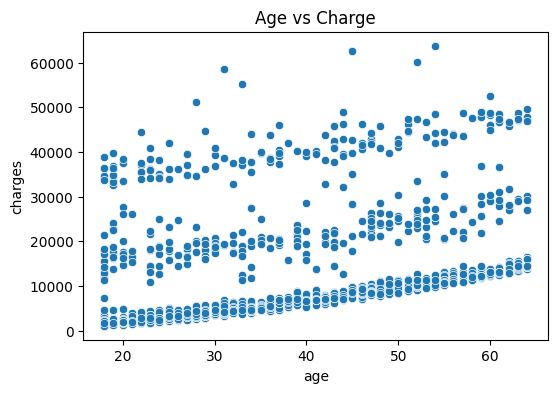

In [34]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='age',y='charges',data=df)
plt.title("Age vs Charge")

In [35]:
df_encoded=pd.get_dummies(df,drop_first=True)
df_encoded

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1332,50,30.970,3,10600.54830,True,False,True,False,False
1333,18,31.920,0,2205.98080,False,False,False,False,False
1334,18,36.850,0,1629.83350,False,False,False,True,False
1335,21,25.800,0,2007.94500,False,False,False,False,True


In [38]:
X=df_encoded.drop("charges",axis=1)
y=df['charges']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [39]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_pred=lr.predict(x_test)

from sklearn.metrics import mean_squared_error,r2_score

mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("MSE: ",mse,"\nRMSE: ",rmse,"\nR2_score: ",r2_score(y_test,y_pred))

MSE:  35478020.67523558 
RMSE:  5956.342894363585 
R2_score:  0.8069287081198013


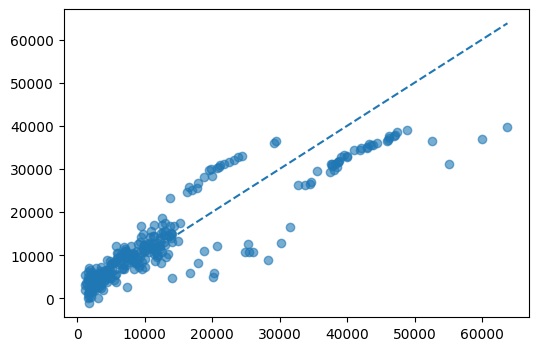

In [45]:
plt.figure(figsize=(6,4))
plt.scatter(y_test,y_pred,alpha=0.6)
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         linestyle="--")
plt.show()